# RNNs and Sequence Models
### Interactive Notebook for AI/ML Interview Preparation

Implements RNN, LSTM, and GRU cells from scratch with NumPy.

📺 **Video Lecture:** [https://youtu.be/G3vQTk-kq9g](https://youtu.be/G3vQTk-kq9g)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Simple RNN Cell

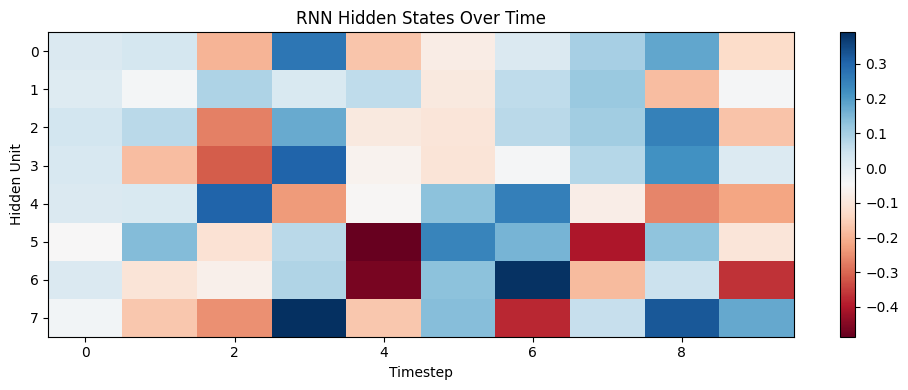

In [2]:
class SimpleRNN:
    def __init__(self, input_dim, hidden_dim):
        self.Wx = np.random.randn(input_dim, hidden_dim) * 0.1
        self.Wh = np.random.randn(hidden_dim, hidden_dim) * 0.1
        self.b = np.zeros(hidden_dim)
        self.hidden_dim = hidden_dim
    
    def forward(self, x_sequence):
        """Process a sequence, return all hidden states."""
        seq_len = len(x_sequence)
        h = np.zeros(self.hidden_dim)
        hidden_states = []
        for t in range(seq_len):
            h = np.tanh(x_sequence[t] @ self.Wx + h @ self.Wh + self.b)
            hidden_states.append(h.copy())
        return np.array(hidden_states)

# Process a sequence of 10 timesteps, 4-dim input, 8-dim hidden
rnn = SimpleRNN(input_dim=4, hidden_dim=8)
x_seq = np.random.randn(10, 4)  # 10 timesteps
hidden_states = rnn.forward(x_seq)

plt.figure(figsize=(10, 4))
plt.imshow(hidden_states.T, aspect='auto', cmap='RdBu')
plt.xlabel('Timestep'); plt.ylabel('Hidden Unit')
plt.title('RNN Hidden States Over Time'); plt.colorbar()
plt.tight_layout(); plt.show()

---
## 2. LSTM Cell from Scratch

In [3]:
class LSTMCell:
    def __init__(self, input_dim, hidden_dim):
        d = input_dim + hidden_dim
        self.Wf = np.random.randn(d, hidden_dim) * 0.1  # forget gate
        self.Wi = np.random.randn(d, hidden_dim) * 0.1  # input gate
        self.Wc = np.random.randn(d, hidden_dim) * 0.1  # candidate
        self.Wo = np.random.randn(d, hidden_dim) * 0.1  # output gate
        self.bf = np.zeros(hidden_dim)
        self.bi = np.zeros(hidden_dim)
        self.bc = np.zeros(hidden_dim)
        self.bo = np.zeros(hidden_dim)
        self.hidden_dim = hidden_dim
    
    def sigmoid(self, x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def forward(self, x_seq):
        h = np.zeros(self.hidden_dim)
        c = np.zeros(self.hidden_dim)
        states = []
        for x in x_seq:
            combined = np.concatenate([x, h])
            f = self.sigmoid(combined @ self.Wf + self.bf)  # forget
            i = self.sigmoid(combined @ self.Wi + self.bi)  # input
            c_hat = np.tanh(combined @ self.Wc + self.bc)   # candidate
            c = f * c + i * c_hat                           # cell state
            o = self.sigmoid(combined @ self.Wo + self.bo)  # output
            h = o * np.tanh(c)                              # hidden state
            states.append(h.copy())
        return np.array(states)

lstm = LSTMCell(input_dim=4, hidden_dim=8)
h_lstm = lstm.forward(x_seq)
print(f'LSTM processed {len(x_seq)} timesteps → hidden states shape: {h_lstm.shape}')

LSTM processed 10 timesteps → hidden states shape: (10, 8)


---
## 3. Vanishing Gradient in RNNs

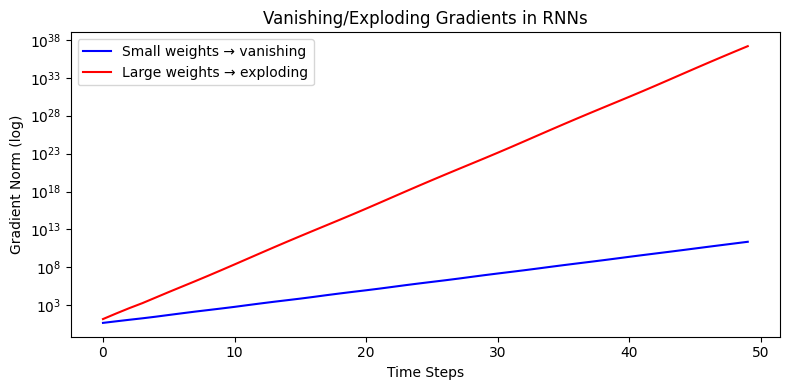

LSTM solves this with gating: forget gate controls information flow


In [4]:
# Demonstrate: multiply small weight matrices repeatedly
hidden_dim = 10
W_small = np.random.randn(hidden_dim, hidden_dim) * 0.5  # small weights
W_large = np.random.randn(hidden_dim, hidden_dim) * 1.5  # large weights

grad_small = np.eye(hidden_dim)
grad_large = np.eye(hidden_dim)
norms_small, norms_large = [], []

for t in range(50):
    grad_small = grad_small @ W_small
    grad_large = grad_large @ W_large
    norms_small.append(np.linalg.norm(grad_small))
    norms_large.append(np.linalg.norm(grad_large))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(norms_small, 'b-', label='Small weights → vanishing')
ax.semilogy(norms_large, 'r-', label='Large weights → exploding')
ax.set_xlabel('Time Steps'); ax.set_ylabel('Gradient Norm (log)')
ax.set_title('Vanishing/Exploding Gradients in RNNs')
ax.legend(); plt.tight_layout(); plt.show()
print('LSTM solves this with gating: forget gate controls information flow')

---
## 4. Beam Search

In [5]:
def beam_search(start_token, probs_fn, beam_width=3, max_len=5):
    """Simple beam search for sequence generation."""
    beams = [(start_token, 0.0)]  # (sequence, log_prob)
    for step in range(max_len):
        candidates = []
        for seq, score in beams:
            probs = probs_fn(seq)  # next token probabilities
            top_k = np.argsort(probs)[-beam_width:]
            for token in top_k:
                candidates.append((seq + [token], score + np.log(probs[token] + 1e-10)))
        beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]
    return beams

# Simulate with random probabilities
vocab = ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'ran', 'fast']
def fake_probs(seq):
    p = np.random.dirichlet(np.ones(len(vocab)))
    return p

results = beam_search([0], fake_probs, beam_width=3, max_len=4)
print('Beam Search Results:')
for seq, score in results:
    words = ' '.join([vocab[t] for t in seq])
    print(f'  Score: {score:.3f} → {words}')

Beam Search Results:
  Score: -3.884 → the ran on cat fast
  Score: -4.074 → the ran on on ran
  Score: -4.156 → the ran on cat sat


---
## Key Interview Takeaways

1. **RNN** — h_t = tanh(W_x·x_t + W_h·h_{t-1}); suffers vanishing gradients
2. **LSTM** — forget/input/output gates control information flow; solves vanishing gradient
3. **GRU** — simplified LSTM with update and reset gates; fewer parameters
4. **Vanishing gradient** — gradients shrink exponentially over time steps
5. **Beam search** — explores multiple hypotheses; better than greedy decoding

---

<small><em>© 2026 AI Nirvana · Disclaimer: Provided as is. No liability assumed.</em></small>